In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

### Loading a CSV file into a DataFrame

To load a CSV file into a pandas DataFrame, you typically use the `pd.read_csv()` function. You can specify the file path to your CSV file as the argument.

In [ ]:
# Example of loading a CSV file into a DataFrame:
# Assuming 'your_file.csv' is in the current directory or you provide the full path
# df_example = pd.read_csv('your_file.csv')

# As an example, here's how the previous '311_Service_Requests_from_2010_to_Present.csv' was loaded:
# df = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv')
# display(df.head())

In [ ]:
df = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv')
display(df.head())

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv')
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '311_Service_Requests_from_2010_to_Present.csv'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 311_Service_Requests_from_2010_to_Present.csv.zip to 311_Service_Requests_from_2010_to_Present.csv.zip


In [ ]:
!unzip -o '311_Service_Requests_from_2010_to_Present.csv.zip'
df = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv')
df.head()

Archive:  311_Service_Requests_from_2010_to_Present.csv.zip
  inflating: 311_Service_Requests_from_2010_to_Present.csv  


/tmp/ipykernel_5480/3736601503.py:2: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv')


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [ ]:
print(df.shape)
print(df.columns)
df.info()

(364558, 53)
Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot N

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values
df = df.fillna("Unknown")

In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

/tmp/ipykernel_5480/12745884.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
/tmp/ipykernel_5480/12745884.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')


In [ ]:
df['Resolution_Delay'] = (
    df['Closed Date'] - df['Created Date']
).dt.days

In [ ]:
priority_levels = ['Low', 'Medium', 'High']

df['Priority'] = np.random.choice(
    priority_levels,
    size=len(df)
)

In [ ]:
priority_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

df['Severity_Score'] = df['Priority'].map(priority_map)

In [ ]:
df['Satisfaction_Score'] = np.random.randint(
    1,
    6,
    size=len(df)
)

In [ ]:
total_complaints = len(df)
print("Total Complaints:", total_complaints)

Total Complaints: 364558


In [ ]:
resolved = df['Status'].eq('Closed').sum()

print("Resolved Complaints:", resolved)

Resolved Complaints: 362114


In [ ]:
resolution_rate = (
    resolved / total_complaints
) * 100

print("Resolution Rate:", round(resolution_rate,2))

Resolution Rate: 99.33


In [ ]:
avg_resolution = df['Resolution_Delay'].mean()

print("Average Resolution Time:", round(avg_resolution,2))

Average Resolution Time: 0.01


In [ ]:
high_priority = (
    df['Priority'] == 'High'
).sum()

print(high_priority)

121589


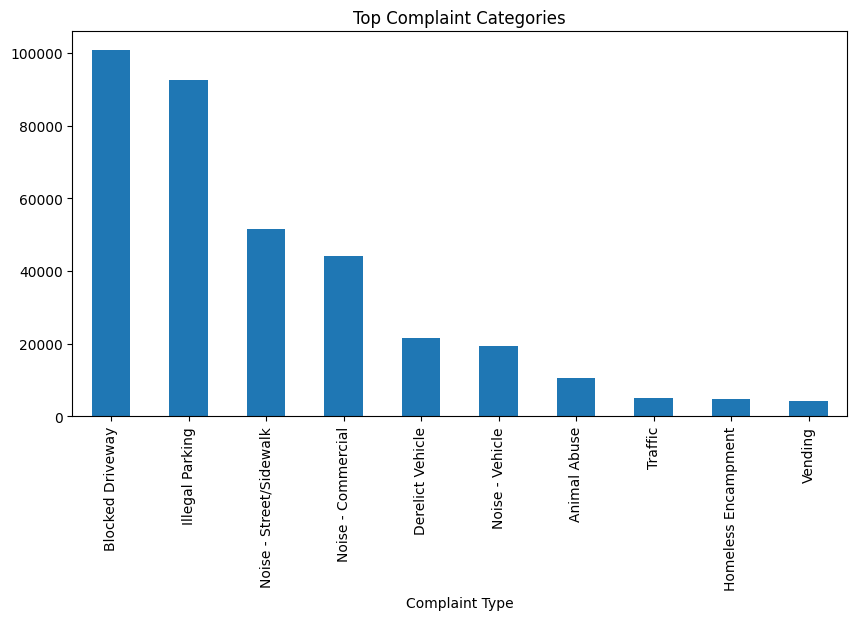

In [ ]:
plt.figure(figsize=(10,5))

df['Complaint Type'].value_counts().head(10).plot(kind='bar')

plt.title("Top Complaint Categories")
plt.show()

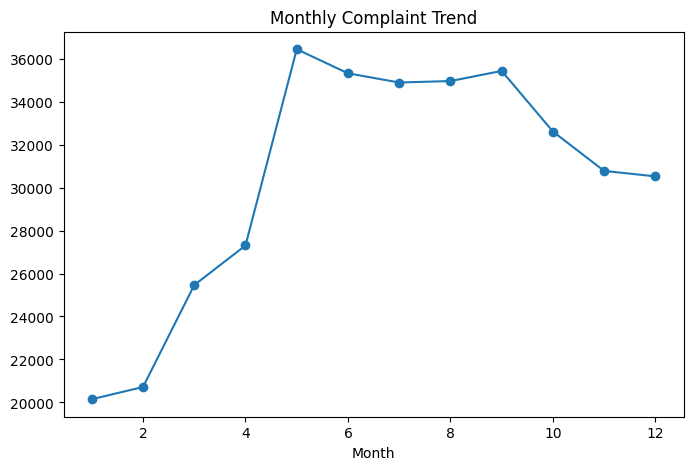

In [ ]:
df['Month'] = df['Created Date'].dt.month

monthly = df.groupby('Month').size()

plt.figure(figsize=(8,5))
monthly.plot(marker='o')

plt.title("Monthly Complaint Trend")
plt.show()

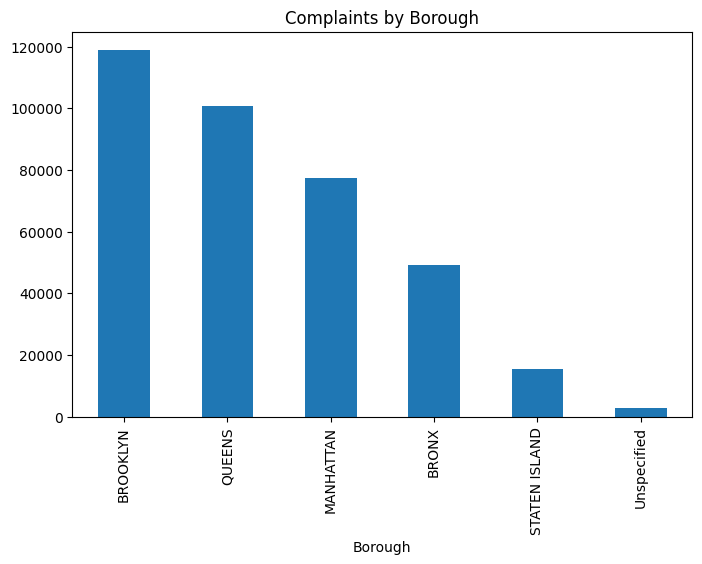

In [ ]:
plt.figure(figsize=(8,5))

df['Borough'].value_counts().plot(kind='bar')

plt.title("Complaints by Borough")
plt.show()

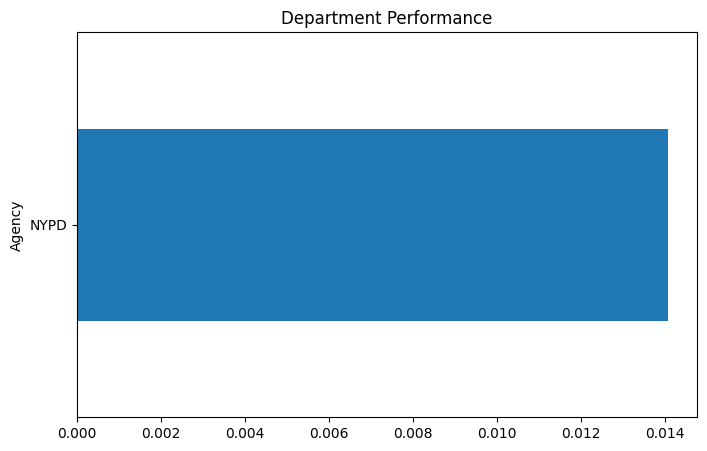

In [ ]:
dept = df.groupby(
    'Agency'
)['Resolution_Delay'].mean().sort_values()

dept.head(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Department Performance")
plt.show()

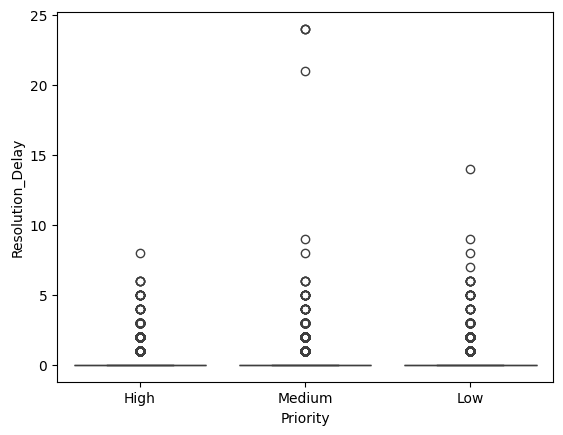

In [ ]:
sns.boxplot(
    x='Priority',
    y='Resolution_Delay',
    data=df
)

plt.show()

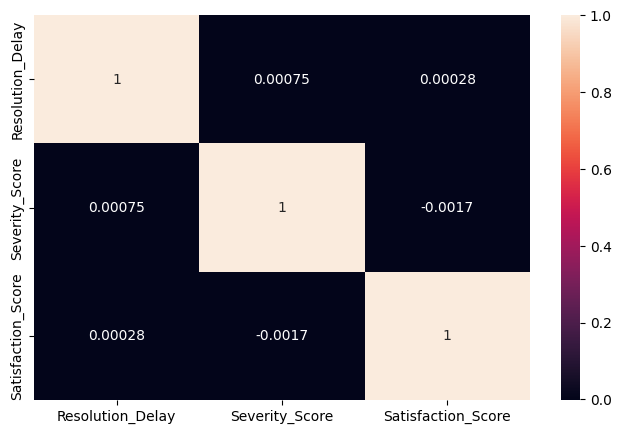

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Resolution_Delay',
        'Severity_Score',
        'Satisfaction_Score']].corr(),
    annot=True
)

plt.show()

In [ ]:
print(
    df['Complaint Type']
    .value_counts()
    .idxmax()
)

Blocked Driveway


In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

/tmp/ipykernel_8820/12745884.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
/tmp/ipykernel_8820/12745884.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')


In [ ]:
df['Resolution_Delay'] = (
    df['Closed Date'] - df['Created Date']
).dt.days

display(df[['Created Date', 'Closed Date', 'Resolution_Delay']].head())

,Created Date,Closed Date,Resolution_Delay
0,2015-12-31 23:59:45,2016-01-01 00:55:15,0.0
1,2015-12-31 23:59:44,2016-01-01 01:26:57,0.0
2,2015-12-31 23:59:29,2016-01-01 04:51:03,0.0
3,2015-12-31 23:57:46,2016-01-01 07:43:13,0.0
4,2015-12-31 23:56:58,2016-01-01 03:24:42,0.0


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving 311_Service_Requests_from_2010_to_Present.csv.zip to 311_Service_Requests_from_2010_to_Present.csv.zip
User uploaded file "311_Service_Requests_from_2010_to_Present.csv.zip" with length 33547759 bytes


In [ ]:
print(
    df['Borough']
    .value_counts()
    .idxmax()
)

BROOKLYN


In [ ]:
print(
    df.groupby('Agency')
    ['Resolution_Delay']
    .mean()
    .idxmax()
)

KeyError: 'Column not found: Resolution_Delay'

In [ ]:
print(df.columns)

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [ ]:
df.to_csv(
    'cleaned_complaints.csv',
    index=False
)